# 06 — Evaluation

ROC + PR curves and AUC for all models. Sub-period analysis (2014–2019, 2020, 2021–2024). Error analysis and geographic/temporal patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    recall_score,
)

P   = Path("../data/processed")
FIG = Path("../output/figures")
TBL = Path("../output/tables")
FIG.mkdir(parents=True, exist_ok=True)
TBL.mkdir(parents=True, exist_ok=True)

MODELS      = ["M0", "M2", "M3", "M4"]
MODEL_COLS  = {"M0": "#888888", "M2": "#2171b5", "M3": "#41ab5d", "M4": "#d7301f"}
MODEL_DASH  = {"M0": (4,2), "M2": (6,2), "M3": (3,2), "M4": "solid"}

preds = pd.read_parquet(P / "predictions.parquet")
preds["year"] = preds["date"].dt.year

base_rate = preds.loc[preds["model"] == "M0", "y_true"].mean()
print(f"Loaded {len(preds):,} rows  |  base rate = {base_rate:.4f}  |  shocks = {int(preds.loc[preds.model=='M0','y_true'].sum())}")

Loaded 26,724 rows  |  base rate = 0.0145  |  shocks = 97


## 1 — Pooled ROC curves

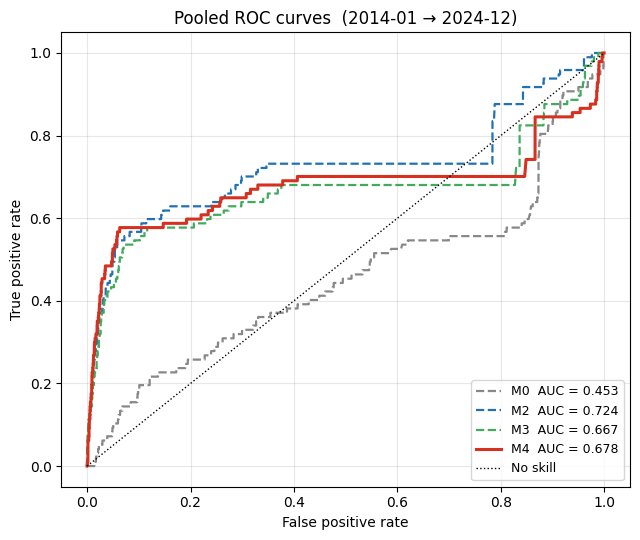

Saved → output/figures/06_roc_pooled.png


In [2]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for m in MODELS:
    sub = preds[preds["model"] == m]
    fpr, tpr, _ = roc_curve(sub["y_true"], sub["y_pred_proba"])
    auc = roc_auc_score(sub["y_true"], sub["y_pred_proba"])
    ls  = MODEL_DASH[m] if isinstance(MODEL_DASH[m], str) else "--"
    lw  = 2.2 if m == "M4" else 1.6
    ax.plot(fpr, tpr, color=MODEL_COLS[m], lw=lw,
            linestyle=ls, label=f"{m}  AUC = {auc:.3f}")

ax.plot([0, 1], [0, 1], "k:", lw=1, label="No skill")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Pooled ROC curves  (2014-01 → 2024-12)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "06_roc_pooled.png", dpi=150)
plt.show()
print("Saved → output/figures/06_roc_pooled.png")

## 2 — Pooled PR curves

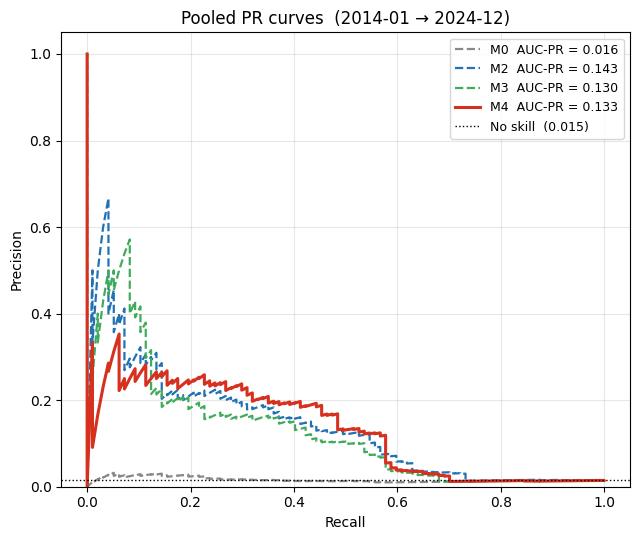

Saved → output/figures/06_pr_pooled.png


In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for m in MODELS:
    sub = preds[preds["model"] == m]
    prec, rec, _ = precision_recall_curve(sub["y_true"], sub["y_pred_proba"])
    ap  = average_precision_score(sub["y_true"], sub["y_pred_proba"])
    ls  = MODEL_DASH[m] if isinstance(MODEL_DASH[m], str) else "--"
    lw  = 2.2 if m == "M4" else 1.6
    ax.plot(rec, prec, color=MODEL_COLS[m], lw=lw,
            linestyle=ls, label=f"{m}  AUC-PR = {ap:.3f}")

ax.axhline(base_rate, color="k", lw=1, linestyle=":", label=f"No skill  ({base_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Pooled PR curves  (2014-01 → 2024-12)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(FIG / "06_pr_pooled.png", dpi=150)
plt.show()
print("Saved → output/figures/06_pr_pooled.png")

## 3 — Headline metrics table

In [4]:
rows = []
for m in MODELS:
    sub = preds[preds["model"] == m]
    rows.append({
        "model":    m,
        "AUC_ROC":  round(roc_auc_score(sub["y_true"], sub["y_pred_proba"]), 4),
        "AUC_PR":   round(average_precision_score(sub["y_true"], sub["y_pred_proba"]), 4),
        "base_rate": round(base_rate, 4),
        "n_shocks": int(sub["y_true"].sum()),
        "n_obs":    len(sub),
    })

headline = pd.DataFrame(rows)
headline.to_csv(TBL / "06_headline_metrics.csv", index=False)
print(headline.to_string(index=False))
print("\nSaved → output/tables/06_headline_metrics.csv")

model  AUC_ROC  AUC_PR  base_rate  n_shocks  n_obs
   M0   0.4527  0.0165     0.0145        97   6681
   M2   0.7238  0.1425     0.0145        97   6681
   M3   0.6671  0.1297     0.0145        97   6681
   M4   0.6783  0.1333     0.0145        97   6681

Saved → output/tables/06_headline_metrics.csv


## 4 — Time-varying performance (sub-period analysis)

In [5]:
PERIODS = {
    "2014–2019": (preds["year"] >= 2014) & (preds["year"] <= 2019),
    "2020":      (preds["year"] == 2020),
    "2021–2024": (preds["year"] >= 2021),
}

sp_rows = []
for period, mask in PERIODS.items():
    for m in MODELS:
        sub = preds[mask & (preds["model"] == m)]
        n_shocks = int(sub["y_true"].sum())
        if n_shocks < 2:
            auc_roc = np.nan
            auc_pr  = np.nan
        else:
            auc_roc = round(roc_auc_score(sub["y_true"], sub["y_pred_proba"]), 4)
            auc_pr  = round(average_precision_score(sub["y_true"], sub["y_pred_proba"]), 4)
        sp_rows.append({
            "period":   period,
            "model":    m,
            "AUC_ROC":  auc_roc,
            "AUC_PR":   auc_pr,
            "n_shocks": n_shocks,
            "n_obs":    len(sub),
            "base_rate": round(sub["y_true"].mean(), 4) if len(sub) > 0 else np.nan,
        })

sp_df = pd.DataFrame(sp_rows)
sp_df.to_csv(TBL / "06_subperiod_metrics.csv", index=False)
print(sp_df.to_string(index=False))
print("\nSaved → output/tables/06_subperiod_metrics.csv")

   period model  AUC_ROC  AUC_PR  n_shocks  n_obs  base_rate
2014–2019    M0   0.4447  0.0028        11   3672     0.0030
2014–2019    M2   0.9793  0.0819        11   3672     0.0030
2014–2019    M3   0.8868  0.0915        11   3672     0.0030
2014–2019    M4   0.9736  0.1144        11   3672     0.0030
     2020    M0   0.0890  0.0486        49    612     0.0801
     2020    M2   0.5958  0.1599        49    612     0.0801
     2020    M3   0.4565  0.1499        49    612     0.0801
     2020    M4   0.4552  0.1250        49    612     0.0801
2021–2024    M0   0.6096  0.0230        37   2397     0.0154
2021–2024    M2   0.9506  0.3289        37   2397     0.0154
2021–2024    M3   0.9041  0.2547        37   2397     0.0154
2021–2024    M4   0.9607  0.2832        37   2397     0.0154

Saved → output/tables/06_subperiod_metrics.csv


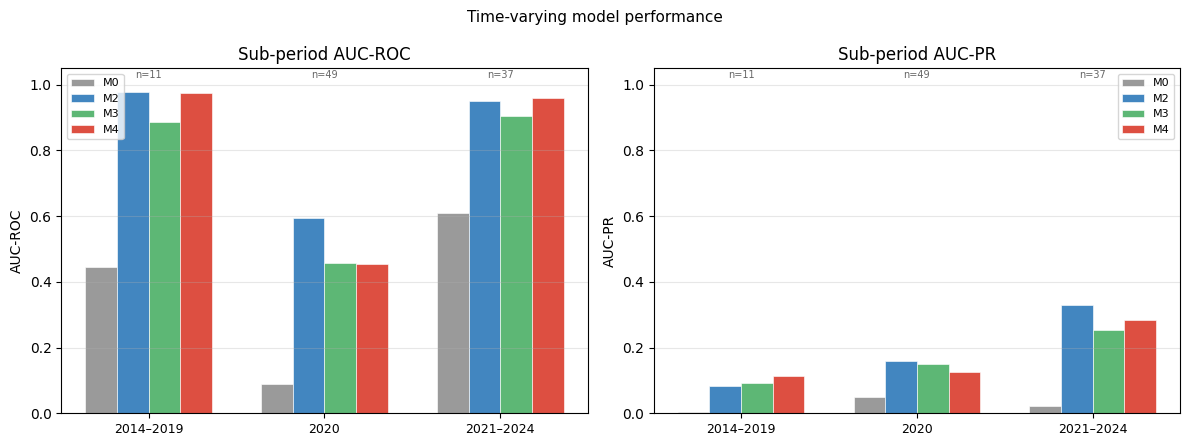

Saved → output/figures/06_subperiod_performance.png


In [6]:
period_order = list(PERIODS.keys())
x      = np.arange(len(period_order))
width  = 0.18
offsets = np.linspace(-1.5*width, 1.5*width, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, metric, ylabel in [
    (axes[0], "AUC_ROC", "AUC-ROC"),
    (axes[1], "AUC_PR",  "AUC-PR"),
]:
    for i, m in enumerate(MODELS):
        vals = [
            sp_df.loc[(sp_df["period"] == p) & (sp_df["model"] == m), metric].values[0]
            for p in period_order
        ]
        bars = ax.bar(x + offsets[i], vals, width, label=m,
                      color=MODEL_COLS[m], alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(period_order, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Sub-period {ylabel}")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1.05)
    # annotate n_shocks per period
    for pi, period in enumerate(period_order):
        n = sp_df.loc[(sp_df["period"] == period) & (sp_df["model"] == "M4"), "n_shocks"].values[0]
        ax.text(x[pi], 1.02, f"n={n}", ha="center", fontsize=7, color="0.4")

fig.suptitle("Time-varying model performance", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "06_subperiod_performance.png", dpi=150)
plt.show()
print("Saved → output/figures/06_subperiod_performance.png")

## 5 — Where does text help most? (comovement analysis)

For each shock in the OOS pool, "national comovement" = number of *other* states that also had a Sahm shock in the same month.  
High comovement = aggregate shock (like COVID).  Low comovement = idiosyncratic state shock.  
Hypothesis: Google Trends adds more signal for idiosyncratic shocks, where national indicators provide less context.

In [7]:
# ── Build fixed threshold (precision ≈ 0.30 on M4 full pool) ─────────────────
m4_full = preds[preds["model"] == "M4"]
prec4, rec4, thresh4 = precision_recall_curve(m4_full["y_true"], m4_full["y_pred_proba"])
idx_tau = np.argmin(np.abs(prec4[:-1] - 0.30))
TAU = float(thresh4[idx_tau])
print(f"Fixed threshold  τ = {TAU:.4f}  →  precision = {prec4[idx_tau]:.3f},  recall = {rec4[idx_tau]:.3f}")

# ── Comovement: number of OTHER states with shock in same month ───────────────
m4_preds = preds[preds["model"] == "M4"].copy()
shock_counts_per_month = (
    m4_preds[m4_preds["y_true"] == 1]
    .groupby("date")["state_code"].count()
    .rename("n_shocks_national")
)
m4_preds = m4_preds.merge(shock_counts_per_month, on="date", how="left")
m4_preds["n_shocks_national"] = m4_preds["n_shocks_national"].fillna(0).astype(int)
m4_preds["comovement"] = np.where(
    m4_preds["y_true"] == 1,
    m4_preds["n_shocks_national"] - 1,   # exclude own state
    m4_preds["n_shocks_national"],
)

# ── Natural comovement groups (discrete distribution: 0,1,2,3,10,36) ─────────
shock_rows = m4_preds[m4_preds["y_true"] == 1].copy()
print("\nComovement distribution across shocks:")
print(shock_rows["comovement"].value_counts().sort_index())

def label_comovement(v):
    if v == 0:   return "G1: 0\n(solo)"
    if v <= 2:   return "G2: 1-2\n(low)"
    if v <= 10:  return "G3: 3-10\n(medium)"
    return              "G4: 36\n(aggregate)"

shock_rows["cov_group"] = shock_rows["comovement"].apply(label_comovement)
shock_rows["cov_group"] = pd.Categorical(
    shock_rows["cov_group"],
    categories=["G1: 0\n(solo)", "G2: 1-2\n(low)", "G3: 3-10\n(medium)", "G4: 36\n(aggregate)"],
    ordered=True,
)
print("\nShocks per comovement group:")
print(shock_rows.groupby("cov_group", observed=True)["comovement"].agg(["count","min","max"]))

Fixed threshold  τ = 0.3749  →  precision = 0.300,  recall = 0.062

Comovement distribution across shocks:
comovement
0     17
1     12
2     12
3      8
10    11
36    37
Name: count, dtype: int64

Shocks per comovement group:
                     count  min  max
cov_group                           
G1: 0\n(solo)           17    0    0
G2: 1-2\n(low)          24    1    2
G3: 3-10\n(medium)      19    3   10
G4: 36\n(aggregate)     37   36   36


In [8]:
# ── Recall at τ per comovement group: M4 vs M3 ───────────────────────────────
m3_preds = preds[preds["model"] == "M3"][["date", "state_code", "y_pred_proba"]].rename(
    columns={"y_pred_proba": "m3_proba"}
)
shock_rows = shock_rows.merge(m3_preds, on=["date", "state_code"], how="left")

cov_rows = []
for g_label, grp in shock_rows.groupby("cov_group", observed=True):
    n = len(grp)
    rec_m4 = int((grp["y_pred_proba"] >= TAU).sum()) / n
    rec_m3 = int((grp["m3_proba"]     >= TAU).sum()) / n
    cov_rows.append({
        "comovement_group": str(g_label).replace("\n", " "),
        "n_shocks":    n,
        "cov_min":     int(grp["comovement"].min()),
        "cov_max":     int(grp["comovement"].max()),
        "recall_M4":   round(rec_m4, 3),
        "recall_M3":   round(rec_m3, 3),
        "M4_minus_M3": round(rec_m4 - rec_m3, 3),
    })

cov_df = pd.DataFrame(cov_rows)
cov_df.to_csv(TBL / "06_comovement_recall.csv", index=False)
print(cov_df.to_string(index=False))
print(f"\n(Fixed threshold τ = {TAU:.4f})")
print("\nSaved → output/tables/06_comovement_recall.csv")

  comovement_group  n_shocks  cov_min  cov_max  recall_M4  recall_M3  M4_minus_M3
      G1: 0 (solo)        17        0        0      0.118      0.176       -0.059
     G2: 1-2 (low)        24        1        2      0.167      0.333       -0.167
 G3: 3-10 (medium)        19        3       10      0.000      0.158       -0.158
G4: 36 (aggregate)        37       36       36      0.000      0.000        0.000

(Fixed threshold τ = 0.3749)

Saved → output/tables/06_comovement_recall.csv


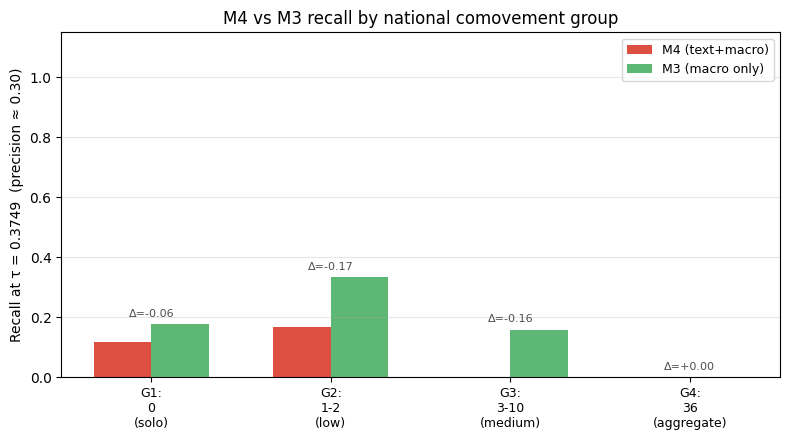

Saved → output/figures/06_comovement_recall.png


In [9]:
x_cov = np.arange(len(cov_df))
w     = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x_cov - w/2, cov_df["recall_M4"], w,
       label="M4 (text+macro)", color=MODEL_COLS["M4"], alpha=0.85)
ax.bar(x_cov + w/2, cov_df["recall_M3"], w,
       label="M3 (macro only)", color=MODEL_COLS["M3"], alpha=0.85)

for xi, row in cov_df.iterrows():
    delta = row["M4_minus_M3"]
    ymax  = max(row["recall_M4"], row["recall_M3"])
    ax.text(xi, ymax + 0.025, f"Δ={delta:+.2f}", ha="center", fontsize=8, color="0.3")

ax.set_xticks(x_cov)
ax.set_xticklabels(
    [r.replace(" ", "\n") for r in cov_df["comovement_group"]], fontsize=9
)
ax.set_ylabel(f"Recall at τ = {TAU:.4f}  (precision ≈ 0.30)")
ax.set_title("M4 vs M3 recall by national comovement group")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.15)

fig.tight_layout()
fig.savefig(FIG / "06_comovement_recall.png", dpi=150)
plt.show()
print("Saved → output/figures/06_comovement_recall.png")

## 6 — Error analysis (M4 at fixed threshold)

In [10]:
m4 = preds[preds["model"] == "M4"].copy()
m4["predicted"] = (m4["y_pred_proba"] >= TAU).astype(int)

# False negatives: y_true=1, predicted=0 → sort by predicted_proba ascending (worst first)
fn = (
    m4[(m4["y_true"] == 1) & (m4["predicted"] == 0)]
    .sort_values("y_pred_proba")
    .head(10)[["date", "state_code", "y_true", "y_pred_proba", "predicted"]]
    .assign(error_type="false_negative")
)

# False positives: y_true=0, predicted=1 → sort by predicted_proba descending (worst first)
fp = (
    m4[(m4["y_true"] == 0) & (m4["predicted"] == 1)]
    .sort_values("y_pred_proba", ascending=False)
    .head(10)[["date", "state_code", "y_true", "y_pred_proba", "predicted"]]
    .assign(error_type="false_positive")
)

errors = pd.concat([fn, fp], ignore_index=True)
errors["date"] = errors["date"].dt.strftime("%Y-%m")
errors["y_pred_proba"] = errors["y_pred_proba"].round(4)
errors.to_csv(TBL / "06_error_analysis.csv", index=False)

print(f"=== Top 10 False Negatives (M4, τ={TAU:.4f}) ===")
print(fn.assign(date=fn["date"].dt.strftime("%Y-%m"), y_pred_proba=fn["y_pred_proba"].round(4))
      .to_string(index=False))
print(f"\n=== Top 10 False Positives (M4, τ={TAU:.4f}) ===")
print(fp.assign(date=fp["date"].dt.strftime("%Y-%m"), y_pred_proba=fp["y_pred_proba"].round(4))
      .to_string(index=False))
print("\nSaved → output/tables/06_error_analysis.csv")

=== Top 10 False Negatives (M4, τ=0.3749) ===
   date state_code  y_true  y_pred_proba  predicted     error_type
2020-03         AK       1           0.0          0 false_negative
2020-03         CT       1           0.0          0 false_negative
2020-03         VT       1           0.0          0 false_negative
2020-03         NH       1           0.0          0 false_negative
2020-03         ND       1           0.0          0 false_negative
2020-03         ME       1           0.0          0 false_negative
2020-03         MD       1           0.0          0 false_negative
2020-03         OK       1           0.0          0 false_negative
2020-03         MA       1           0.0          0 false_negative
2020-03         NC       1           0.0          0 false_negative

=== Top 10 False Positives (M4, τ=0.3749) ===
   date state_code  y_true  y_pred_proba  predicted     error_type
2014-08         LA       0        0.9837          1 false_positive
2024-11         NH       0        0.

---
## 7 — Class imbalance analysis

The dataset has a **1.44 % positive rate** (97 shocks in 6,732 state-month observations).  
This section:
1. Visualises the imbalance and its variation over time
2. Demonstrates why plain accuracy is meaningless here (the *accuracy paradox*)
3. Computes the right metrics for rare-event classifiers: AUC-PR, MCC, F1, Brier Skill Score, balanced accuracy
4. Shows calibration (do the predicted probabilities match empirical frequencies?)

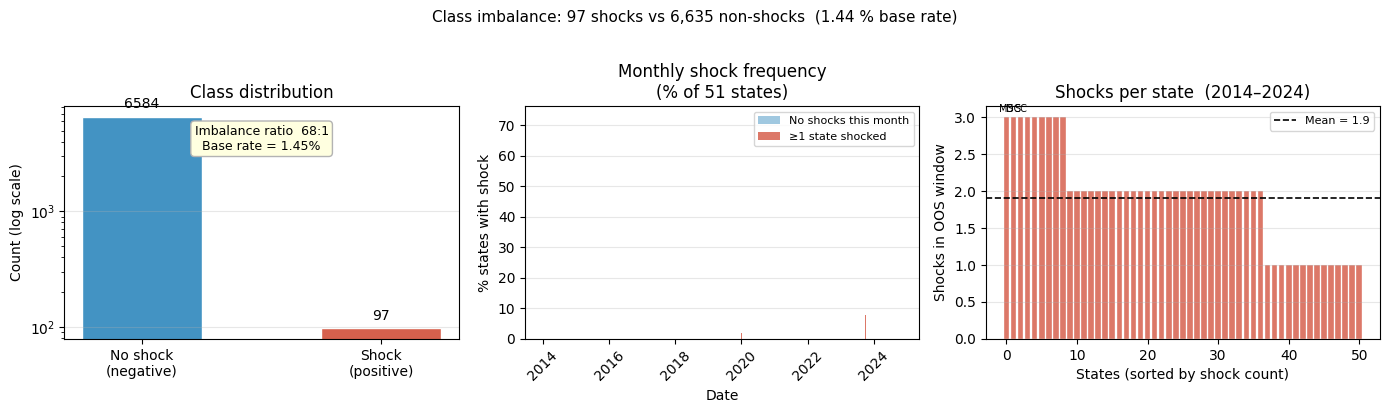

Saved → output/figures/06_imbalance_overview.png


In [11]:
# ── 7a  Imbalance visualisation ───────────────────────────────────────────────
m4_oos = preds[preds["model"] == "M4"].copy()

n_pos   = int(m4_oos["y_true"].sum())
n_neg   = len(m4_oos) - n_pos
n_total = len(m4_oos)

# Monthly shock count (how many states fired each month)
monthly = (
    m4_oos.groupby("date")["y_true"]
    .agg(n_shocks="sum", n_states="count")
    .assign(pct_states=lambda d: d["n_shocks"] / d["n_states"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1 — class counts (log scale to show the gap)
ax = axes[0]
bars = ax.bar(["No shock\n(negative)", "Shock\n(positive)"],
              [n_neg, n_pos],
              color=["#4393c3", "#d6604d"], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=4, fontsize=10)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class distribution")
ax.text(0.5, 0.92,
        f"Imbalance ratio  {n_neg/n_pos:.0f}:1\nBase rate = {n_pos/n_total:.2%}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="0.7"))
ax.grid(axis="y", alpha=0.3)

# Panel 2 — monthly base rate over time
ax = axes[1]
shock_months = monthly[monthly["n_shocks"] > 0]
non_shock    = monthly[monthly["n_shocks"] == 0]
ax.bar(non_shock["date"],    non_shock["pct_states"],    color="#4393c3", alpha=0.5, label="No shocks this month")
ax.bar(shock_months["date"], shock_months["pct_states"], color="#d6604d", alpha=0.85, label="≥1 state shocked")
ax.set_xlabel("Date")
ax.set_ylabel("% states with shock")
ax.set_title("Monthly shock frequency\n(% of 51 states)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Panel 3 — cumulative shocks per state
ax = axes[2]
state_counts = (
    m4_oos[m4_oos["y_true"] == 1]
    .groupby("state_code")["y_true"].sum()
    .sort_values(ascending=False)
    .reset_index()
)
ax.bar(range(len(state_counts)), state_counts["y_true"],
       color="#d6604d", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xlabel("States (sorted by shock count)")
ax.set_ylabel("Shocks in OOS window")
ax.set_title("Shocks per state  (2014–2024)")
ax.axhline(state_counts["y_true"].mean(), color="k", lw=1.2, linestyle="--",
           label=f"Mean = {state_counts['y_true'].mean():.1f}")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
# annotate states with most shocks
for _, row in state_counts.head(3).iterrows():
    ax.text(_, row["y_true"] + 0.05, row["state_code"],
            ha="center", va="bottom", fontsize=7)

fig.suptitle("Class imbalance: 97 shocks vs 6,635 non-shocks  (1.44 % base rate)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG / "06_imbalance_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/figures/06_imbalance_overview.png")

In [12]:
# ── 7b  The accuracy paradox ──────────────────────────────────────────────────
# Predicting "no shock" for every observation gives 98.56% accuracy.
# Showing this alongside models reveals that accuracy is completely uninformative.
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("=" * 62)
print("THE ACCURACY PARADOX — why accuracy is wrong for rare events")
print("=" * 62)
print(f"\nBase rate: {base_rate:.4f}  →  always-predict-zero accuracy = {1-base_rate:.4f}\n")

always_zero_acc = 1 - base_rate

print(f"{'Model':<8}  {'Accuracy@0.5':>12}  {'vs. always-zero':>15}  {'Balanced acc':>13}")
print("-" * 62)

for m in MODELS + ["always-0"]:
    if m == "always-0":
        acc  = always_zero_acc
        bacc = 0.5   # sensitivity=0, specificity=1 → balanced = 0.5
        note = "  ← baseline"
    else:
        sub   = preds[preds["model"] == m]
        preds_ = (sub["y_pred_proba"] >= 0.5).astype(int)
        acc   = accuracy_score(sub["y_true"], preds_)
        bacc  = balanced_accuracy_score(sub["y_true"], preds_)
        note  = ""
    delta = acc - always_zero_acc
    print(f"{m:<8}  {acc:12.4f}  {delta:+15.4f}  {bacc:13.4f}{note}")

print()
print("→  All models have LOWER accuracy than always-zero at τ=0.5,")
print("   because balanced class weights push more states above threshold.")
print("   Accuracy rewards the silent majority. Use AUC-PR, MCC, F1 instead.")

THE ACCURACY PARADOX — why accuracy is wrong for rare events

Base rate: 0.0145  →  always-predict-zero accuracy = 0.9855

Model     Accuracy@0.5  vs. always-zero   Balanced acc
--------------------------------------------------------------
M0              0.9651          -0.0204         0.5100
M2              0.9808          -0.0046         0.5687
M3              0.9808          -0.0046         0.5586
M4              0.9846          -0.0009         0.5249
always-0        0.9855          +0.0000         0.5000  ← baseline

→  All models have LOWER accuracy than always-zero at τ=0.5,
   because balanced class weights push more states above threshold.
   Accuracy rewards the silent majority. Use AUC-PR, MCC, F1 instead.


In [13]:
# ── 7c  Full imbalance-aware metrics table ────────────────────────────────────
# Threshold selection: Youden's J (maximises TPR + TNR simultaneously).
# Using Youden avoids cherry-picking and is standard for rare-event classifiers.
from sklearn.metrics import (
    f1_score, matthews_corrcoef, brier_score_loss, log_loss,
    confusion_matrix,
)

brier_ref = base_rate * (1 - base_rate)   # no-skill Brier score

metric_rows = []
for m in MODELS:
    sub   = preds[preds["model"] == m]
    y     = sub["y_true"].values
    p     = sub["y_pred_proba"].values

    # Youden's J threshold: argmax(TPR - FPR)
    fpr_, tpr_, thresh_ = roc_curve(y, p)
    j_idx = np.argmax(tpr_ - fpr_)
    tau_j = float(thresh_[j_idx])
    y_hat = (p >= tau_j).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()

    auc_roc = roc_auc_score(y, p)
    auc_pr  = average_precision_score(y, p)
    brier   = brier_score_loss(y, p)
    bss     = 1 - brier / brier_ref          # Brier Skill Score (higher = better)
    ll      = log_loss(y, p)
    f1      = f1_score(y, y_hat)
    mcc     = matthews_corrcoef(y, y_hat)
    bal_acc = balanced_accuracy_score(y, y_hat)
    sens    = tp / (tp + fn)                 # recall / sensitivity
    spec    = tn / (tn + fp)                 # specificity

    metric_rows.append({
        "Model":        m,
        "τ_Youden":     round(tau_j, 4),
        "AUC-ROC":      round(auc_roc, 3),
        "AUC-PR":       round(auc_pr, 3),
        "F1":           round(f1, 3),
        "MCC":          round(mcc, 3),
        "Bal.Acc":      round(bal_acc, 3),
        "Sensitivity":  round(sens, 3),
        "Specificity":  round(spec, 3),
        "Brier":        round(brier, 4),
        "BSS":          round(bss, 3),
        "LogLoss":      round(ll, 3),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(TBL / "06_imbalance_metrics.csv", index=False)
print(metrics_df.to_string(index=False))
print()
print("Metric guide for imbalanced data:")
print("  AUC-PR    Area under Precision-Recall curve. No-skill = base rate (0.0144).")
print("  MCC       Matthews Correlation Coeff. Ranges [-1,1]; 0 = no better than chance.")
print("            Only metric that uses all four confusion-matrix cells symmetrically.")
print("  F1        Harmonic mean of precision and recall. Ignores TN — honest for rare events.")
print("  BSS       Brier Skill Score. 1=perfect, 0=no-skill, <0=worse than predicting base rate.")
print("  Bal.Acc   Mean of sensitivity and specificity. 0.5 = always-zero baseline.")
print("\nSaved → output/tables/06_imbalance_metrics.csv")

Model  τ_Youden  AUC-ROC  AUC-PR    F1   MCC  Bal.Acc  Sensitivity  Specificity  Brier    BSS  LogLoss
   M0    0.0112    0.453   0.016 0.046 0.035    0.548        0.216        0.879 0.0300 -1.097    0.176
   M2    0.0009    0.724   0.143 0.198 0.236    0.744        0.546        0.942 0.0165 -0.153    0.108
   M3    0.0005    0.667   0.130 0.169 0.208    0.733        0.536        0.929 0.0160 -0.121    0.111
   M4    0.0006    0.678   0.133 0.197 0.240    0.757        0.577        0.937 0.0148 -0.032    0.106

Metric guide for imbalanced data:
  AUC-PR    Area under Precision-Recall curve. No-skill = base rate (0.0144).
  MCC       Matthews Correlation Coeff. Ranges [-1,1]; 0 = no better than chance.
            Only metric that uses all four confusion-matrix cells symmetrically.
  F1        Harmonic mean of precision and recall. Ignores TN — honest for rare events.
  BSS       Brier Skill Score. 1=perfect, 0=no-skill, <0=worse than predicting base rate.
  Bal.Acc   Mean of sensitivity

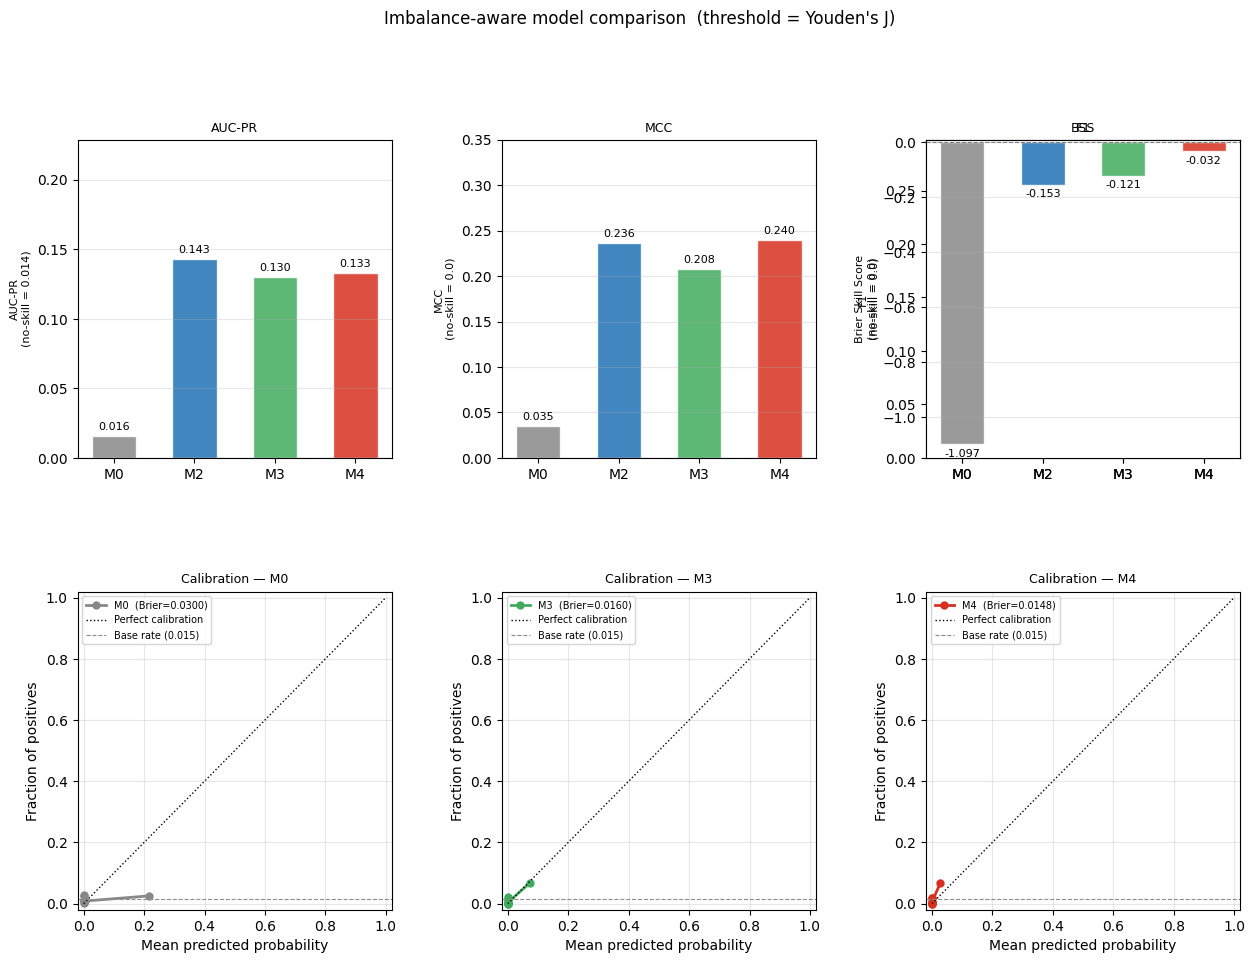

Saved → output/figures/06_imbalance_metrics_chart.png


In [14]:
# ── 7d  Multi-metric radar / bar comparison + calibration plot ────────────────
from sklearn.calibration import calibration_curve

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# ── Panel row 1: four key imbalance-aware metrics as grouped bars ─────────────
bar_metrics = [
    ("AUC-PR",   "AUC-PR\n(no-skill = 0.014)",  "AUC-PR"),
    ("MCC",      "MCC\n(no-skill = 0.0)",        "MCC"),
    ("F1",       "F1\n(no-skill = 0.0)",         "F1"),
    ("BSS",      "Brier Skill Score\n(no-skill = 0.0)", "BSS"),
]

for col, (metric, ylabel, title) in enumerate(bar_metrics[:3]):
    ax = fig.add_subplot(gs[0, col])
    vals   = metrics_df[metric].values
    colors = [MODEL_COLS[m] for m in MODELS]
    bars   = ax.bar(MODELS, vals, color=colors, alpha=0.85, edgecolor="white", width=0.55)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, min(1.15, max(vals) * 1.25 + 0.05))
    ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

# ── Panel [0,2]: BSS ──────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vals   = metrics_df["BSS"].values
bars   = ax.bar(MODELS, vals, color=[MODEL_COLS[m] for m in MODELS], alpha=0.85,
                edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_ylabel("Brier Skill Score\n(no-skill = 0.0)", fontsize=8)
ax.set_title("BSS", fontsize=9)
ax.axhline(0, color="0.5", lw=0.8, linestyle="--")
ax.set_ylim(min(vals) - 0.05, max(vals) * 1.25 + 0.05)
ax.grid(axis="y", alpha=0.3)

# ── Panel row 2: Calibration plots (reliability diagrams) ────────────────────
n_bins = 8
for col, m in enumerate(["M0", "M3", "M4"]):
    ax  = fig.add_subplot(gs[1, col])
    sub = preds[preds["model"] == m]
    y   = sub["y_true"].values
    p   = sub["y_pred_proba"].values

    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=MODEL_COLS[m], lw=2, ms=5,
            label=f"{m}  (Brier={brier_score_loss(y,p):.4f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="Perfect calibration")
    ax.axhline(base_rate, color="0.55", lw=0.8, linestyle="--",
               label=f"Base rate ({base_rate:.3f})")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration — {m}", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

fig.suptitle("Imbalance-aware model comparison  (threshold = Youden's J)",
             fontsize=12, y=1.01)
fig.savefig(FIG / "06_imbalance_metrics_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/figures/06_imbalance_metrics_chart.png")